# kNN：找到最近的 k 个邻居

前面几篇文章的算法都有一个共同点：**从训练数据里学出参数**——线性回归的权重、决策树的分裂阈值、SVM 的超平面。

kNN 不学任何参数。给定一个新样本，它在训练集里找最近的 k 个样本，用多数投票决定类别。整个训练过程只是把数据存下来，没有梯度下降、没有迭代。

本文用 numpy 实现 kNN，在 Iris 数据集上验证分类效果，对比不同 k 值和距离度量对决策边界的影响。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier as SkKNN

import sys, os
sys.path.insert(0, os.path.abspath('..'))
from models.knn import KNN

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
np.random.seed(42)

## 1. 数据集

**Iris 数据集**：3 类、4 个特征。展示 kNN 在多类问题上的效果。

**月牙数据集**（make_moons）：2 类、2 个特征，非线性可分。用于可视化不同 k 值下的决策边界。

In [2]:
# --- Iris ---
iris = load_iris()
X_ir, y_ir = iris.data, iris.target

X_ir_train, X_ir_test, y_ir_train, y_ir_test = train_test_split(
    X_ir, y_ir, test_size=0.2, random_state=1
)

# kNN 对特征尺度敏感（距离被量纲大的特征主导），标准化
scaler = StandardScaler()
X_ir_train = scaler.fit_transform(X_ir_train)
X_ir_test = scaler.transform(X_ir_test)

print(f'Iris: {X_ir.shape[0]} 样本, {X_ir.shape[1]} 特征, 类别={list(iris.target_names)}')
print(f'  训练集 {len(X_ir_train)} / 测试集 {len(X_ir_test)}')
print()

# --- 月牙 ---
X_m, y_m = make_moons(n_samples=300, noise=0.15, random_state=1)
print(f'Moons: {X_m.shape[0]} 样本, {X_m.shape[1]} 特征, 类别={np.unique(y_m).tolist()}')

Iris: 150 样本, 4 特征, 类别=['setosa', 'versicolor', 'virginica']
  训练集 120 / 测试集 30

Moons: 300 样本, 2 特征, 类别=[0, 1]


## 2. 在 Iris 上训练 kNN

kNN 的 fit 阶段只是把训练数据存下来——不需要任何梯度下降或迭代。

In [3]:
knn = KNN(k=5, weights='uniform', metric='euclidean')
knn.fit(X_ir_train, y_ir_train)

pred_train = knn.predict(X_ir_train)
pred_test = knn.predict(X_ir_test)

acc_train = (pred_train == y_ir_train).mean()
acc_test = (pred_test == y_ir_test).mean()

print(f'k=5 训练集准确率: {acc_train*100:.1f}%')
print(f'k=5 测试集准确率:  {acc_test*100:.1f}%')
print(f'训练样本数: {len(X_ir_train)}（kNN 把它们全记住了）')

k=5 训练集准确率: 95.8%
k=5 测试集准确率:  96.7%
训练样本数: 120（kNN 把它们全记住了）


## 3. 决策边界：k 值的影响

kNN 的决策边界由训练数据决定。不同的 k 值会画出完全不同的边界：

- **k=1**：每个测试样本只看最近的 1 个训练样本，边界紧贴训练点（容易过拟合）
- **k 适中**：边界平滑，能捕捉数据的主要结构
- **k 太大**：边界过于平滑，远离每个区域（欠拟合）

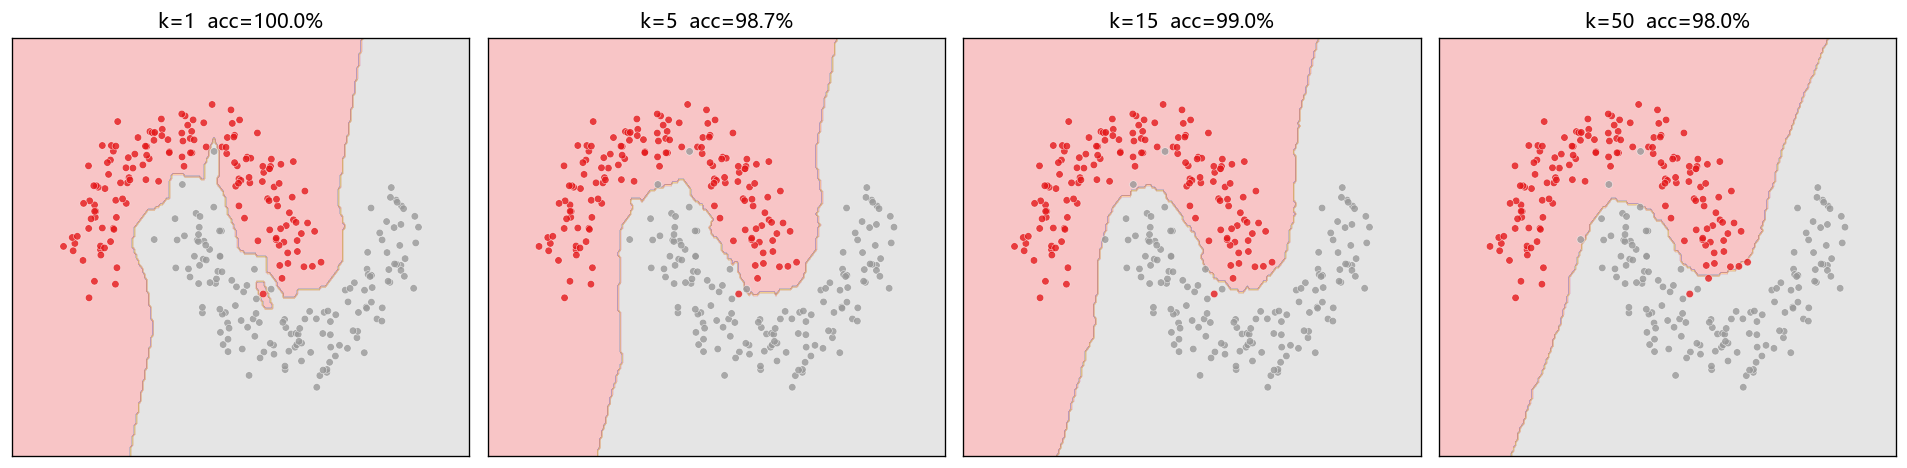

In [4]:
def plot_knn_boundary(model, X, y, ax, title):
    """画 2D 决策边界。"""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='Set1')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='Set1',
               s=20, alpha=0.8, edgecolors='white', linewidth=0.3)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])


fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, k in zip(axes, [1, 5, 15, 50]):
    m = KNN(k=k)
    m.fit(X_m, y_m)
    acc = (m.predict(X_m) == y_m).mean()
    plot_knn_boundary(m, X_m, y_m, ax, f'k={k}  acc={acc*100:.1f}%')

plt.tight_layout()
plt.show()

## 4. k 值扫描

在 Iris 数据集上扫描 k 从 1 到 30，看训练集和测试集准确率的变化。

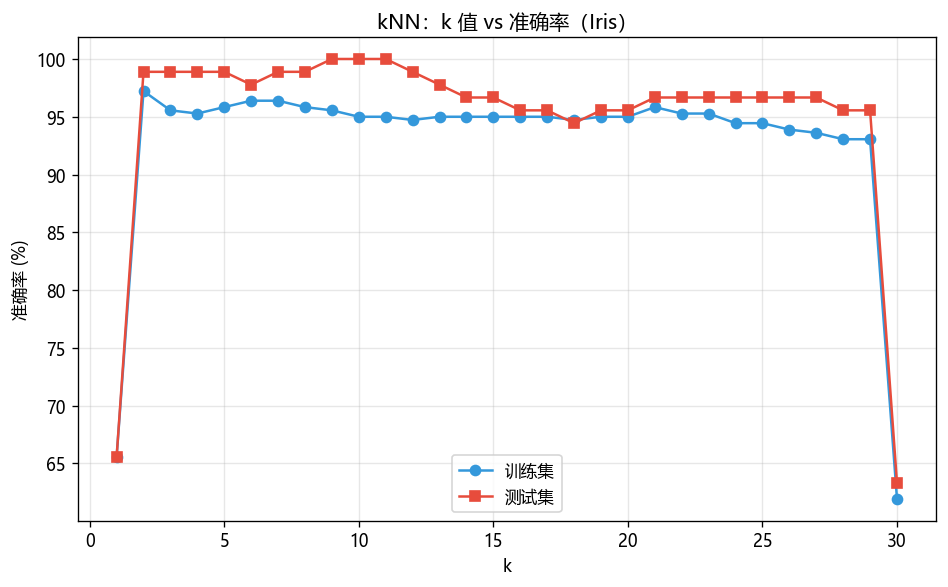

测试集最佳 k: 1 (准确率 100.0%)
k=1 时训练集准确率: 100.0% （记住全部训练点）
k=30 时训练集准确率: 93.3% （多数投票退化为多数类）


In [5]:
k_values = list(range(1, 31))
train_scores, test_scores = [], []

for k in k_values:
    m = KNN(k=k)
    m.fit(X_ir_train, y_ir_train)
    train_scores.append((m.predict(X_ir_train) == y_ir_train).mean())
    test_scores.append((m.predict(X_ir_test) == y_ir_test).mean())

def smooth(y, w=3):
    return np.convolve(y, np.ones(w)/w, mode='same')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_values, [s*100 for s in smooth(train_scores)], 'o-', label='训练集', color='#3498db')
ax.plot(k_values, [s*100 for s in smooth(test_scores)], 's-', label='测试集', color='#e74c3c')
ax.set_xlabel('k')
ax.set_ylabel('准确率 (%)')
ax.set_title('kNN：k 值 vs 准确率（Iris）')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(range(0, 31, 5))
plt.tight_layout()
plt.show()

best_k = k_values[int(np.argmax(test_scores))]
print(f'测试集最佳 k: {best_k} (准确率 {max(test_scores)*100:.1f}%)')
print(f'k=1 时训练集准确率: {train_scores[0]*100:.1f}% （记住全部训练点）')
print(f'k=30 时训练集准确率: {train_scores[-1]*100:.1f}% （多数投票退化为多数类）')


## 5. 距离度量对比

kNN 的核心是距离。两种最常用的距离：

- **欧氏距离** $\|x - y\|_2$：直线距离，对量纲敏感
- **曼哈顿距离** $\|x - y\|_1$：坐标轴方向距离之和，对稀疏特征友好

在 Iris 上两种距离效果接近，但决策边界形状会略有差异。

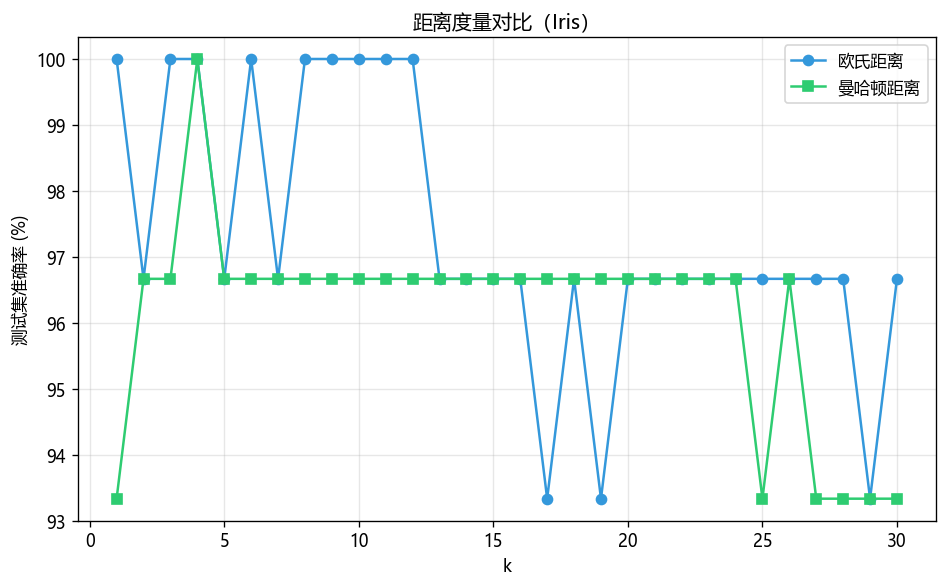

欧氏距离最佳: k=1, 准确率 100.0%
曼哈顿距离最佳: k=4, 准确率 100.0%


In [6]:
euc_scores, man_scores = [], []
for k in k_values:
    m_e = KNN(k=k, metric='euclidean')
    m_e.fit(X_ir_train, y_ir_train)
    euc_scores.append((m_e.predict(X_ir_test) == y_ir_test).mean())

    m_m = KNN(k=k, metric='manhattan')
    m_m.fit(X_ir_train, y_ir_train)
    man_scores.append((m_m.predict(X_ir_test) == y_ir_test).mean())

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_values, [s*100 for s in euc_scores], 'o-', label='欧氏距离', color='#3498db')
ax.plot(k_values, [s*100 for s in man_scores], 's-', label='曼哈顿距离', color='#2ecc71')
ax.set_xlabel('k')
ax.set_ylabel('测试集准确率 (%)')
ax.set_title('距离度量对比（Iris）')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(range(0, 31, 5))
plt.tight_layout()
plt.show()

print(f'欧氏距离最佳: k={k_values[int(np.argmax(euc_scores))]}, '
      f'准确率 {max(euc_scores)*100:.1f}%')
print(f'曼哈顿距离最佳: k={k_values[int(np.argmax(man_scores))]}, '
      f'准确率 {max(man_scores)*100:.1f}%')

## 6. 权重方案：uniform vs distance

kNN 投票时，每个邻居的权重可以相同（uniform），也可以按距离倒数加权（distance）。距离越近的邻居，权重越大。

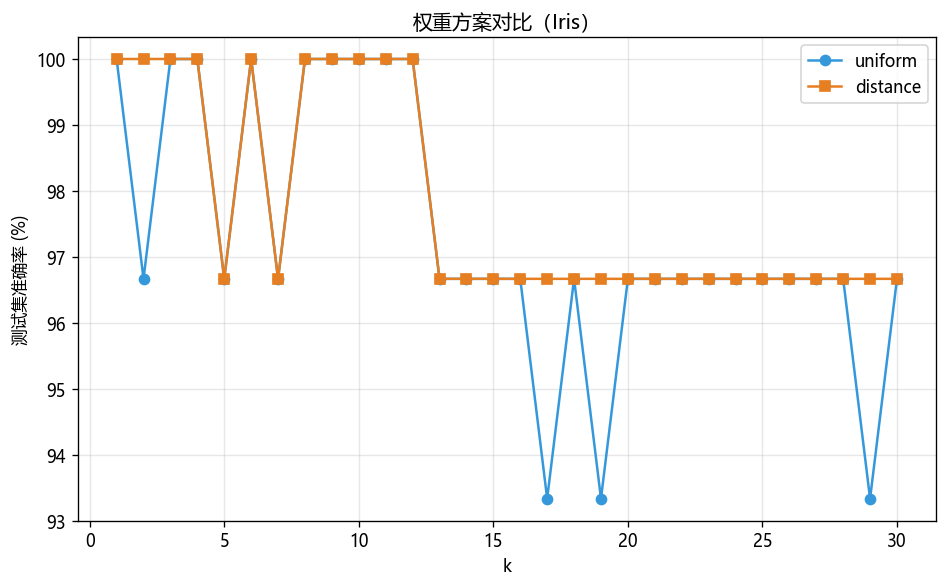

uniform 最佳: k=1, 准确率 100.0%
distance 最佳: k=1, 准确率 100.0%


In [7]:
uni_scores, dist_scores = [], []
for k in k_values:
    m_u = KNN(k=k, weights='uniform')
    m_u.fit(X_ir_train, y_ir_train)
    uni_scores.append((m_u.predict(X_ir_test) == y_ir_test).mean())

    m_d = KNN(k=k, weights='distance')
    m_d.fit(X_ir_train, y_ir_train)
    dist_scores.append((m_d.predict(X_ir_test) == y_ir_test).mean())

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_values, [s*100 for s in uni_scores], 'o-', label='uniform', color='#3498db')
ax.plot(k_values, [s*100 for s in dist_scores], 's-', label='distance', color='#e67e22')
ax.set_xlabel('k')
ax.set_ylabel('测试集准确率 (%)')
ax.set_title('权重方案对比（Iris）')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(range(0, 31, 5))
plt.tight_layout()
plt.show()

print(f'uniform 最佳: k={k_values[int(np.argmax(uni_scores))]}, '
      f'准确率 {max(uni_scores)*100:.1f}%')
print(f'distance 最佳: k={k_values[int(np.argmax(dist_scores))]}, '
      f'准确率 {max(dist_scores)*100:.1f}%')

## 7. 与 sklearn 对比

验证我们的 kNN 实现和 sklearn 的 KNeighborsClassifier 结果一致。

In [8]:
results = {}
for k in [1, 5, 15]:
    our_m = KNN(k=k)
    our_m.fit(X_ir_train, y_ir_train)
    our_acc = (our_m.predict(X_ir_test) == y_ir_test).mean()

    sk_m = SkKNN(n_neighbors=k)
    sk_m.fit(X_ir_train, y_ir_train)
    sk_acc = (sk_m.predict(X_ir_test) == y_ir_test).mean()

    match = 'Yes' if abs(our_acc - sk_acc) < 0.02 else 'Check'
    results[k] = (our_acc, sk_acc, match)

print(f"{'k':<5} {'Our kNN':<12} {'sklearn':<12} {'Match':<8}")
print('-' * 40)
for k, (o, s, m) in results.items():
    print(f'{k:<5} {o*100:<10.1f}% {s*100:<10.1f}% {m:<8}')

k     Our kNN      sklearn      Match   
----------------------------------------
1     100.0     % 100.0     % Yes     
5     96.7      % 96.7      % Yes     
15    96.7      % 96.7      % Yes     


## 小结

kNN 是最简单的分类器之一，训练阶段只是把数据存下来，预测时找最近的 k 个邻居做多数投票。

- **k 太小**：边界紧贴训练点，容易过拟合
- **k 太大**：边界过于平滑，容易欠拟合
- **distance 权重**：近邻权重大，对噪声更稳健
- **特征标准化**：距离对量纲敏感，必须先标准化
- **计算复杂度**：预测时 O(n)，训练数据大时推理慢

kNN 在低维、小数据集上效果好，但在高维空间（特征数 > 50）会出现「维度灾难」——距离失去区分度，所有点的距离都差不多。对于大规模或高维任务，需要用降维（PCA）、近似最近邻（KD-Tree / LSH）或深度学习。